In [4]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

'cuda'

In [3]:
import torch
import torchvision
import torchvision.transforms.v2 as T
from functools import partial
%pip install torchmetrics -q
import torchmetrics

def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)
    return metric.compute()

def train(model, optimizer, loss_fn, metric, train_loader, valid_loader,
          n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.0
        metric.reset()
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        history["train_losses"].append(total_loss / len(train_loader))
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_tm(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 25.8 MB/s eta 0:00:0000:01


In [5]:
toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

train_and_valid_data = torchvision.datasets.MNIST(
    root='datasets', train=True, download=True, transform=toTensor
)
test_data = torchvision.datasets.MNIST(
    root='datasets', train=False, download=True, transform=toTensor
)
train_data, valid_data = torch.utils.data.random_split(
    train_and_valid_data, [55_000, 5_000]
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 482kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.48MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.66MB/s]


In [6]:
from torch.utils.data import DataLoader
torch.manual_seed(42)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

In [7]:
import torch.nn.functional as F
import torch.nn as nn
class MnistModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.flatten = nn.Flatten()
        self.dropout1 = nn.Dropout(0.25)
        self.fc1 = nn.Linear(1 * 28 * 28 * 32 // 2, 128)
        self.dropout2 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128,10)

        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
    
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = self.flatten(x)
        x = self.dropout1(x)
        x = F.relu(self.fc1(x))
        x = self.dropout2(x)
        return self.fc2(x)

In [8]:
torch.manual_seed(42)
mnist_model = MnistModel().to(device)

In [9]:
n_epochs=10
optimizer = torch.optim.AdamW(mnist_model.parameters())
xentropy = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task='multiclass',
                                 num_classes=10).to(device)
history = train(mnist_model, optimizer, xentropy, accuracy, train_loader,
                valid_loader, n_epochs)

Epoch 1/10, train loss: 0.2221, train metric: 0.9334, valid metric: 0.9760
Epoch 2/10, train loss: 0.0946, train metric: 0.9718, valid metric: 0.9810
Epoch 3/10, train loss: 0.0695, train metric: 0.9789, valid metric: 0.9848
Epoch 4/10, train loss: 0.0556, train metric: 0.9824, valid metric: 0.9854
Epoch 5/10, train loss: 0.0460, train metric: 0.9858, valid metric: 0.9864
Epoch 6/10, train loss: 0.0400, train metric: 0.9878, valid metric: 0.9862
Epoch 7/10, train loss: 0.0338, train metric: 0.9893, valid metric: 0.9884
Epoch 8/10, train loss: 0.0306, train metric: 0.9898, valid metric: 0.9892
Epoch 9/10, train loss: 0.0269, train metric: 0.9912, valid metric: 0.9880
Epoch 10/10, train loss: 0.0269, train metric: 0.9916, valid metric: 0.9902


In [10]:
evaluate_tm(mnist_model, test_loader, accuracy)

tensor(0.9921, device='cuda:0')

In [11]:
from pathlib import Path
import urllib.request
import zipfile

def download_hymenoptera_dataset():
    data_dir = Path("datasets")
    url = "https://download.pytorch.org/tutorial/hymenoptera_data.zip"
    zip_path = data_dir / "hymenoptera_data.zip"
    data_dir.mkdir(parents=True, exist_ok=True)
    if not zip_path.exists():
        print("Downloading...",  end="")
        urllib.request.urlretrieve(url, zip_path)
        print(" Done.")
    unzipped_dir = data_dir / "hymenoptera_data"
    if not unzipped_dir.exists():
        print("Extracting...", end="")
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(data_dir)
        print(" Done.")
    return unzipped_dir

hymenoptera_dir = download_hymenoptera_dataset()

Downloading... Done.
Extracting... Done.


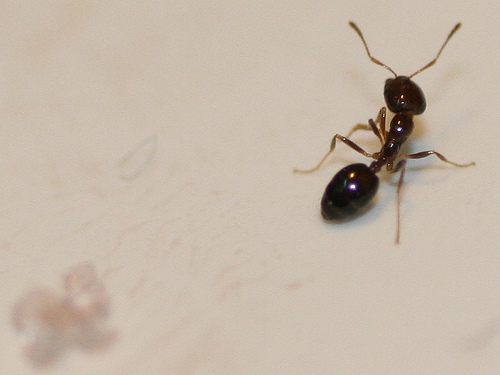

In [12]:
import PIL

PIL.Image.open(hymenoptera_dir / "train" / "ants" / "560966032_988f4d7bc4.jpg")

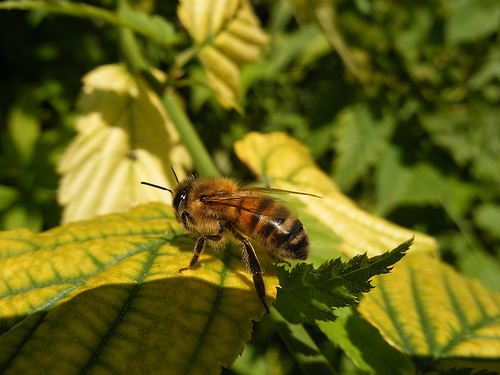

In [13]:
PIL.Image.open(hymenoptera_dir / "train" / "bees" / "760568592_45a52c847f.jpg")

In [14]:
from torchvision.datasets import ImageFolder
import torchvision.transforms.v2 as T

train_transforms = T.Compose([
    T.RandomResizedCrop(224),
    T.RandomHorizontalFlip(),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
valid_test_transforms = T.Compose([
    T.Resize(232),
    T.CenterCrop(224),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
train_set = ImageFolder(hymenoptera_dir / "train", train_transforms)
valid_test_set = ImageFolder(hymenoptera_dir / "val", valid_test_transforms)

torch.manual_seed(42)
valid_set, test_set = torch.utils.data.random_split(valid_test_set, [0.5, 0.5])
class_names = train_set.classes

In [15]:
batch_size = 32
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=batch_size)
test_loader = DataLoader(test_set, batch_size=batch_size)

In [16]:
weights = torchvision.models.ConvNeXt_Base_Weights.IMAGENET1K_V1
model = torchvision.models.convnext_base(weights=weights).to(device)

Downloading: "https://download.pytorch.org/models/convnext_base-6075fbad.pth" to /root/.cache/torch/hub/checkpoints/convnext_base-6075fbad.pth


100%|██████████| 338M/338M [00:02<00:00, 147MB/s] 


In [17]:
model.classifier[2] = nn.Linear(1024, 2).to(device)

In [18]:
model.classifier

Sequential(
  (0): LayerNorm2d((1024,), eps=1e-06, elementwise_affine=True)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=1024, out_features=2, bias=True)
)

In [19]:
for param in model.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

In [20]:
n_epochs = 5
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
xentropy = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=2).to(device)
history = train(model, optimizer, xentropy, accuracy,
                train_loader, valid_loader, n_epochs)

Epoch 1/5, train loss: 0.4842, train metric: 0.8484, valid metric: 1.0000
Epoch 2/5, train loss: 0.2104, train metric: 0.9672, valid metric: 1.0000
Epoch 3/5, train loss: 0.1236, train metric: 0.9713, valid metric: 1.0000
Epoch 4/5, train loss: 0.1082, train metric: 0.9631, valid metric: 1.0000
Epoch 5/5, train loss: 0.0545, train metric: 0.9918, valid metric: 1.0000


In [21]:
evaluate_tm(model, test_loader, accuracy)

tensor(0.9868, device='cuda:0')